In [1]:
import pandas as pd
import numpy as np 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style chung cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Sửa lại đường dẫn: lùi ra ngoài thư mục Notebooks để thấy processed_chunks
path = '../processed_chunks/' 

all_files = glob.glob(os.path.join(path, "train_*.pkl"))

# Kiểm tra xem có tìm thấy file nào không
if not all_files:
    print("Không tìm thấy file nào! Hãy kiểm tra lại đường dẫn.")
else:
    print(f"Tìm thấy {len(all_files)} files. Đang đọc...")
    df_list = [pd.read_pickle(f) for f in all_files]
    full_df = pd.concat(df_list, ignore_index=True)
    print(f"Thành công! Tổng số dòng: {len(full_df)}")


Tìm thấy 18 files. Đang đọc...
Thành công! Tổng số dòng: 1708337


In [2]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1708337 entries, 0 to 1708336
Data columns (total 59 columns):
 #   Column                                        Dtype         
---  ------                                        -----         
 0   channelGrouping                               object        
 1   date                                          datetime64[ns]
 2   fullVisitorId                                 object        
 3   visitId                                       int64         
 4   visitNumber                                   int64         
 5   visitStartTime                                int64         
 6   device_browser                                object        
 7   device_operatingSystem                        object        
 8   device_isMobile                               bool          
 9   device_deviceCategory                         object        
 10  geoNetwork_continent                          object        
 11  geoNetwork_subContinent            

In [3]:
full_df.head()

,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_month_start,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0


In [4]:
full_df.isnull().sum()

channelGrouping                                       0
date                                                  0
fullVisitorId                                         0
visitId                                               0
visitNumber                                           0
visitStartTime                                        0
device_browser                                       12
device_operatingSystem                            11815
device_isMobile                                       0
device_deviceCategory                                 0
geoNetwork_continent                               2517
geoNetwork_subContinent                            2517
geoNetwork_country                                 2517
geoNetwork_region                                982733
geoNetwork_metro                                1319855
geoNetwork_city                                  998826
geoNetwork_networkDomain                         768845
totals_visits                                   

In [5]:
full_df.nunique().sort_values(ascending=False)

visitStartTime                                  1667423
visitStartTime_datetime                         1667423
visitId                                         1665802
fullVisitorId                                   1323730
trafficSource_adwordsClickInfo.gclId              59009
geoNetwork_networkDomain                          41980
totals_totalTransactionRevenue                     8507
target_log_revenue                                 7252
transactionRevenue                                 7252
totals_transactionRevenue                          7252
transactionRevenue_dollar                          7252
totals_timeOnSite                                  4775
trafficSource_keyword                              4546
trafficSource_referralPath                         3197
geoNetwork_city                                     954
date                                                638
geoNetwork_region                                   481
visitNumber                                     

## 📊 Data Dictionary — Google Merchandise Store

**Dataset:** Google Analytics session-level data
**Shape:** 1,708,337 rows × 59 columns · **Memory:** ~697 MB
**Target:** `target_log_revenue` — log1p(transaction revenue)

---

### 1. 🔑 Session Identification (6 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `fullVisitorId` | object | 0 | Unique ID for each visitor |
| `visitId` | int64 | 0 | Session ID (unique per visitor) |
| `visitNumber` | int64 | 0 | Nth visit of this visitor (1 = first visit) |
| `visitStartTime` | int64 | 0 | UNIX timestamp of session start |
| `visitStartTime_datetime` | datetime64 | 0 | Human-readable session start time |
| `date` | datetime64 | 0 | Date of the session |

---

### 2. 📱 Device Information (4 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `device_browser` | object | 12 | Browser used (Chrome, Safari, ...) |
| `device_operatingSystem` | object | 11,815 | OS of the device |
| `device_isMobile` | bool | 0 | True if session was from mobile |
| `device_deviceCategory` | object | 0 | Device type: desktop / mobile / tablet |

---

### 3. 🌍 Geographic Information (7 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `geoNetwork_continent` | object | 2,517 | Continent of the visitor |
| `geoNetwork_subContinent` | object | 2,517 | Sub-continent |
| `geoNetwork_country` | object | 2,517 | Country of the visitor |
| `geoNetwork_region` | object | 982,733 | 🟡 Region/state — high nulls |
| `geoNetwork_metro` | object | 1,319,855 | 🔴 Metro area — very high nulls |
| `geoNetwork_city` | object | 998,826 | 🔴 City — very high nulls |
| `geoNetwork_networkDomain` | object | 768,845 | 🟡 ISP/network domain |

---

### 4. 📈 Session Totals (11 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `totals_visits` | int64 | 0 | Always 1 (one row = one session) |
| `totals_hits` | int64 | 0 | Number of hits in session |
| `totals_pageviews` | int64 | 0 | Pages viewed in session |
| `totals_bounces` | int64 | 0 | 1 if session bounced, else 0 |
| `totals_newVisits` | int64 | 0 | 1 if first-ever visit, else 0 |
| `totals_sessionQualityDim` | int64 | 0 | GA session quality score (1–100) |
| `totals_timeOnSite` | int64 | 0 | Time on site in seconds |
| `totals_transactions` | int64 | 0 | Number of transactions in session |
| `totals_transactionRevenue` | float64 | 0 | Revenue × 10⁶ (raw GA format) (unit: micro) |
| `totals_totalTransactionRevenue` | float64 | 0 | Total revenue × 10⁶ |
| `transactionRevenue` | float64 | 0 | Revenue cleaned (= totals / 10⁶) |

---

### 5. 🚦 Traffic Source (13 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `channelGrouping` | object | 0 | Channel: Organic, Direct, Referral, ... |
| `trafficSource_source` | object | 70 | Traffic source (google, direct, ...) |
| `trafficSource_medium` | object | 566,091 | 🟡 Medium: organic, cpc, referral, ... |
| `trafficSource_campaign` | object | 1,604,526 | 🔴 Campaign name — mostly null |
| `trafficSource_keyword` | object | 0 | Search keyword |
| `trafficSource_referralPath` | object | 0 | Referral URL path |
| `trafficSource_isTrueDirect` | bool | 0 | True if confirmed direct traffic |
| `trafficSource_adContent` | object | 0 | Ad content label |
| `trafficSource_adwordsClickInfo.page` | int64 | 0 | AdWords page number |
| `trafficSource_adwordsClickInfo.slot` | object | 0 | Ad slot position |
| `trafficSource_adwordsClickInfo.gclId` | object | 0 | Google Click ID |
| `trafficSource_adwordsClickInfo.adNetworkType` | object | 0 | Ad network type |
| `trafficSource_adwordsClickInfo.isVideoAd` | bool | 0 | True if video ad click |

---

### 6. 🗓️ Date Features (13 columns — engineered)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `Date_Year` | int32 | 0 | Year |
| `Date_Month` | int32 | 0 | Month (1–12) |
| `Date_Day` | int32 | 0 | Day of month (1–31) |
| `Date_Dayofweek` | int32 | 0 | Day of week (0=Mon, 6=Sun) |
| `Date_Dayofyear` | int32 | 0 | Day of year (1–365) |
| `Date_Week` | Int64 | 0 | ISO week number |
| `Date_Hour` | int32 | 0 | Hour of visit (0–23) |
| `Date_Is_month_end` | int64 | 0 | 1 if last day of month |
| `Date_Is_month_start` | int64 | 0 | 1 if first day of month |
| `Date_Is_quarter_end` | int64 | 0 | 1 if last day of quarter |
| `Date_Is_quarter_start` | int64 | 0 | 1 if first day of quarter |
| `Date_Is_year_end` | int64 | 0 | 1 if last day of year |
| `Date_Is_year_start` | int64 | 0 | 1 if first day of year |

---

### 7. 🎯 Target & Custom Dimensions (5 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `transactionRevenue_dollar` | float64 | 0 | Revenue in USD (cleaned) |
| `target_log_revenue` | float64 | 0 | **Model target** — log1p(revenue) |
| `customDimensions_count` | int64 | 0 | Number of custom dimensions |
| `customDimensions_index` | int64 | 0 | Custom dimension index |
| `customDimensions_value` | object | 0 | Custom dimension value |

---

### ⚠️ Missing Value — Cách xử lý

| Severity | Columns | Cách xử lý |
|---|---|---|
| 🔴 Rất cao (>50%) | `trafficSource_campaign` | Fill `"no_campaign"` — null = không chạy campaign |
| 🔴🟡 Cao | `geoNetwork_metro`, `geoNetwork_city`, `geoNetwork_region` | Fill `"unknown"` |
| 🟡 Cao (~33%) | `trafficSource_medium` | Fill `"none"` — chuẩn GA: null = direct/none |
| 🟡 Cao (~45%) | `geoNetwork_networkDomain` | Không dùng trong model — bỏ qua |
| 🟢 Thấp (<1%) | `device_operatingSystem`, `device_browser`, `trafficSource_source`, `geoNetwork_country`, `geoNetwork_subContinent`, `geoNetwork_continent` | Fill `"unknown"` |

> **Kết quả:** Sau xử lý tất cả cột đều có null = 0.

### 1. GIGO Audit 

Kiểm tra internal traffic, bot....

In [6]:
# 1. Internal traffic (nhân viên test). Dấu hiệu: domain chứa google hoặc city = Mountain View -> test hệ thống, không mua thật 
internal_mask = (
    (full_df['geoNetwork_networkDomain'].astype(str).str.contains('google', na=False)) | 
    (full_df['geoNetwork_city'] == 'Mountain View')
)
print(f'Internal sessions: {internal_mask.sum():,}')
# 2. Bot/crawler: Các chương trình tự động crawl website, không phải người thật. Chúng để lại dấu hiệu bất thường như hits cao nhưng timeOnSite = 0
# pageview cao + bounce = 1 (vào rồi thoát ngay nhưng hits nhiều), browser lạ như ";__CT_JOB_ID..." -> bot không bao giờ mua hàng
bot_mask = (
    ((full_df['totals_hits'] > 500) & (full_df['totals_timeOnSite'] == 0)) |
    ((full_df['totals_pageviews'] > 500) & (full_df['totals_bounces'] == 1)) |
    (full_df['device_browser'].str.contains('CT_JOB_ID|ecgiwap', na=False, regex=True)))
print(f"Bot sessions: {bot_mask.sum():,}")

# 3. Tracking error: users chỉ xem 1 trang duy nhất rồi thoát (không thể vừa bounce vừa mua hàng vì cần min 3-4 pages: page sản phẩm -> giỏ hàng -> thanh toán -> xác nhận)
# bounce = 1 + revenue > 0 = lỗi tracking, không phải giao dịch thật
tracking_error_mask = ((full_df['totals_bounces'] == 1) & (full_df['transactionRevenue'] > 0))
print(f"Tracking errors: {tracking_error_mask.sum():,}")
print(f"Revenue từ nhóm này: ${full_df[tracking_error_mask]['transactionRevenue'].sum():,.2f}")


# 4. Fake Whale: pageviews = 1, timeonsite = 0, revenue lớn (chỉ xem 1 trang, không dành 1 giây nào trên size nhuwngmua hàng giá trị lớn)
fake_whale_mask = ((full_df['totals_pageviews'] <= 1) & (full_df['totals_timeOnSite']==0) & (full_df['transactionRevenue'] >0))
print(f"Fake whales: {fake_whale_mask.sum():,}")
print(f"Revenue trung bình: ${full_df[fake_whale_mask]['transactionRevenue'].mean():,.2f}")
print(f"Revenue max: ${full_df[fake_whale_mask]['transactionRevenue'].max():,.2f}")
print(f"Revenue tổng: ${full_df[fake_whale_mask]['transactionRevenue'].sum():,.2f}")

Internal sessions: 84,598
Bot sessions: 21
Tracking errors: 0
Revenue từ nhóm này: $0.00
Fake whales: 0
Revenue trung bình: $nan
Revenue max: $nan
Revenue tổng: $0.00


Kiểm tra tỷ lệ khách mua hàng thực sự, missing có chủ đích

In [7]:
# Tỷ lệ khách mua hàng thực sự
buyers = (full_df['transactionRevenue'] > 0).sum()
total = len(full_df)
print(f'Khách có mua hàng: {buyers:,} ({buyers/total*100:.2f}%)')
print(f"Khách không mua   : {total-buyers:,} ({(total-buyers)/total*100:.2f}%)")

# Kiểm tra missing có chủ đích ở revenue (98-99% users không mua, chỉ 1-2% có revenue) -> extreme class imbalance
print(f"\nRevenue = 0      : {(full_df['transactionRevenue']==0).sum():,}")
print(f"Revenue > 0      : {(full_df['transactionRevenue']>0).sum():,}")
print(f"Revenue là null  : {full_df['transactionRevenue'].isnull().sum():,}")

Khách có mua hàng: 18,514 (1.08%)
Khách không mua   : 1,689,823 (98.92%)

Revenue = 0      : 1,689,823
Revenue > 0      : 18,514
Revenue là null  : 0


##### Với phần lọc nhiễu phi sản phẩm 
- 18,514 sessions có chênh lệch giữa transactionRevenue 
  và totalTransactionRevenue (tax + shipping)
- 75% hàng: tax/shipping ratio < 22% → bình thường
- 740 hàng: tax > revenue (ratio > 1) → bất thường
- max ratio = 300 → có thể là refund hoặc adjustment

QUYẾT ĐỊNH: 
  Dùng 'transactionRevenue' làm target thay vì 'totalTransactionRevenue'
  vì đây là giá trị hàng hóa thuần, không bị ảnh hưởng bởi 
  tax/shipping bất thường. 'target_log_revenue' đã được tính 
  đúng từ cột này → không cần xử lý thêm.


### 2. Funnel and Pageviews-Revenue

Bộ data là session-lvel, phễu được suy luận từ hits và pageviews:

- hits = 1-2: vào trang chủ, chưa xem gì <br>
- hits = 3-10: đang xem sản phẩm <br>
- hits = 11-20: xem nhiều, đang so sánh <br>
- hits = 20+: engagement cao, gần mua
- transactions = 1: đã thanh toán


In [8]:
# Phân tích ngưỡng pageviews → conversion
bins   = [0, 2, 5, 10, 20, 50, 500]
labels = ['Trang chủ (1-2)', 'Xem SP (3-5)', 
          'Khám phá (6-10)', 'Engaged (11-20)',
          'Deep (21-50)', 'Power (50+)']
full_df['funnel_stage'] = pd.cut(
    full_df['totals_hits'], bins=bins, labels=labels
)

funnel = full_df.groupby('funnel_stage', observed=True).agg(
    sessions       = ('fullVisitorId', 'count'),
    buyers         = ('transactionRevenue', lambda x: (x > 0).sum()),
).assign(
    conversion_rate = lambda x: x['buyers'] / x['sessions'] * 100,
    drop_off_rate   = lambda x: (1 - x['sessions'] / x['sessions'].iloc[0]) * 100
)
print(funnel.round(2))
# → Tìm ngưỡng: xem >10 trang thì conversion rate tăng mạnh
# Kết quả cho thấy tỷ lệ rớt ở từng step


                 sessions  buyers  conversion_rate  drop_off_rate
funnel_stage                                                     
Trang chủ (1-2)   1101563       7             0.00           0.00
Xem SP (3-5)       278997      48             0.02          74.67
Khám phá (6-10)    159757     584             0.37          85.50
Engaged (11-20)    102010    5343             5.24          90.74
Deep (21-50)        55246    9229            16.71          94.98
Power (50+)         10764    3303            30.69          99.02


sessions — số lượt truy cập rơi vào nhóm hits đó <br>
buyers — trong số sessions đó, bao nhiêu lượt có phát sinh mua hàng <br>
conversion_rate — buyers / sessions * 100 — tỷ lệ % mua hàng <br>
drop_off_rate — % sessions đã "rơi ra" so với nhóm đầu tiên (Trang chủ) <br>

-> Điểm gãy ở đây là từ khám phá lên engaged: từ 0.37 nhảy vọt lên 5.24 (gấp 14 lần), số lượng người mua tăng vọt

Mối quan hệ Pageviews - Revenue: Vẽ biểu đồ tán xạ (Scatter Plot) giữa số trang xem và doanh thu. Bạn sẽ tìm thấy một "ngưỡng tâm lý" (ví dụ: khách xem trên 10 trang có xác suất mua cao gấp 5 lần).

In [11]:
pv_analysis = full_df.groupby('totals_pageviews').agg(
    sessions   = ('fullVisitorId', 'count'),
    buyers     = ('transactionRevenue', lambda x: (x > 0).sum()),
).assign(conv_rate = lambda x: x['buyers'] / x['sessions'] * 100)

pv_plot = pv_analysis[pv_analysis.index <= 30].copy()
pv_plot.index = pv_plot.index.astype(int)

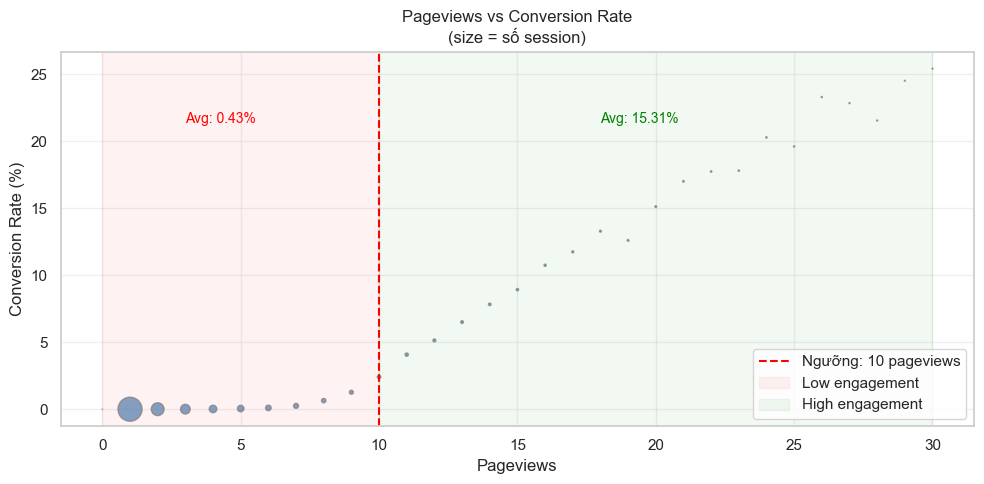

Conv rate ≤ 10 pageviews: 0.43%
Conv rate >  10 pageviews: 15.31%
Tăng: 35.5x


In [12]:
# Dùng ngưỡng cố định dựa trên business insight từ funnel table
threshold = 10  # pageviews > 10 tương ứng hits > 11

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    pv_plot.index,
    pv_plot['conv_rate'],
    s=pv_plot['sessions'] / pv_plot['sessions'].max() * 300,
    alpha=0.7,
    color='steelblue',
    edgecolors='gray'
)

ax.axvline(x=threshold, color='red', linestyle='--',
           label=f'Ngưỡng: {threshold} pageviews')

# Tô màu 2 vùng
ax.axvspan(0, threshold, alpha=0.05, color='red',   label='Low engagement')
ax.axvspan(threshold, 30, alpha=0.05, color='green', label='High engagement')

# Annotation conv rate 2 vùng
below = pv_plot[pv_plot.index <= threshold]['conv_rate'].mean()
above = pv_plot[pv_plot.index > threshold]['conv_rate'].mean()
ax.text(3,  ax.get_ylim()[1]*0.8, f'Avg: {below:.2f}%', color='red',   fontsize=10)
ax.text(18, ax.get_ylim()[1]*0.8, f'Avg: {above:.2f}%', color='green', fontsize=10)

ax.set_xlabel('Pageviews')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Pageviews vs Conversion Rate\n(size = số session)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Conv rate ≤ {threshold} pageviews: {below:.2f}%")
print(f"Conv rate >  {threshold} pageviews: {above:.2f}%")
print(f"Tăng: {above/below:.1f}x")

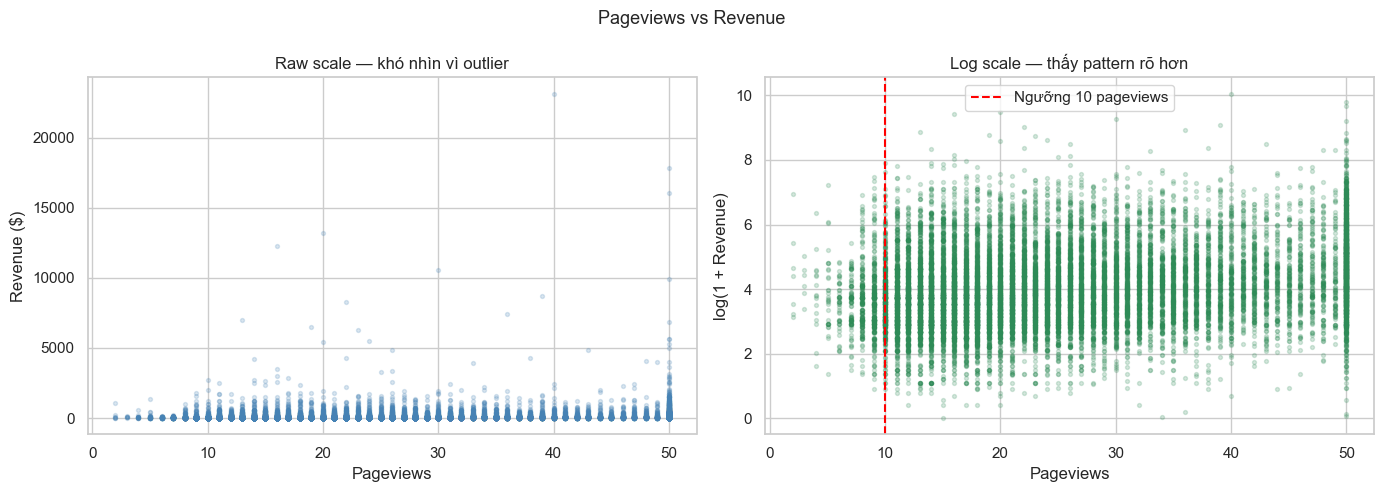

In [13]:
import numpy as np
# Dùng transactionRevenue_dollar và log scale cho trục Y
buyers_df = full_df[full_df['transactionRevenue_dollar'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart trái — raw scale
axes[0].scatter(
    buyers_df['totals_pageviews'].clip(upper=50),
    buyers_df['transactionRevenue_dollar'],
    alpha=0.2, s=8, color='steelblue'
)
axes[0].set_title('Raw scale — khó nhìn vì outlier')
axes[0].set_xlabel('Pageviews')
axes[0].set_ylabel('Revenue ($)')

# Chart phải — log scale trục Y
axes[1].scatter(
    buyers_df['totals_pageviews'].clip(upper=50),
    np.log1p(buyers_df['transactionRevenue_dollar']),
    alpha=0.2, s=8, color='seagreen'
)
axes[1].axvline(x=10, color='red', linestyle='--', 
                label='Ngưỡng 10 pageviews')
axes[1].set_title('Log scale — thấy pattern rõ hơn')
axes[1].set_xlabel('Pageviews')
axes[1].set_ylabel('log(1 + Revenue)')
axes[1].legend()

plt.suptitle('Pageviews vs Revenue', fontsize=13)
plt.tight_layout()
plt.show()

INSIGHT — Pageviews vs Revenue:
- Pageviews cao → mua thường xuyên hơn (số giao dịch nhiều hơn, ảnh hưởng xác suất có mua hay không)
- Pageviews cao → KHÔNG đồng nghĩa revenue cao hơn mỗi giao dịch (không ảnh hưởng đến giá trị đơn hàng)
- Revenue bị chi phối bởi loại sản phẩm, không phải engagement

→ Feature nên tạo:
   is_high_engagement = (hits >= 11)  ← dự báo CÓ mua hay không
   (Không dùng pageviews để dự báo revenue amount)

### 3. Cohort Analysis

Đây là phần giúp bạn hiểu về "độ trung thành" để thiết kế khung thời gian (Window Framing) cho chính xác.

Retention Heatmap: Vẽ biểu đồ nhiệt theo dõi các nhóm khách hàng (Cohort) gia nhập theo tháng. Nếu khách hàng từ tháng 12/2017 có tỷ lệ quay lại cao hơn hẳn tháng 5/2017, bạn cần tìm hiểu xem lúc đó có chiến dịch Marketing nào (trong cột trafficSource) tác động hay không.

Time-to-Buy: Đo lường khoảng thời gian trung bình từ lần đầu truy cập đến khi phát sinh giao dịch đầu tiên. Nếu con số này là 20 ngày, thì khoảng trắng (Gap) 45 ngày trong bài toán Kaggle là một thử thách cực lớn, vì bạn đang phải dự báo xa hơn gấp đôi chu kỳ mua sắm thông thường.

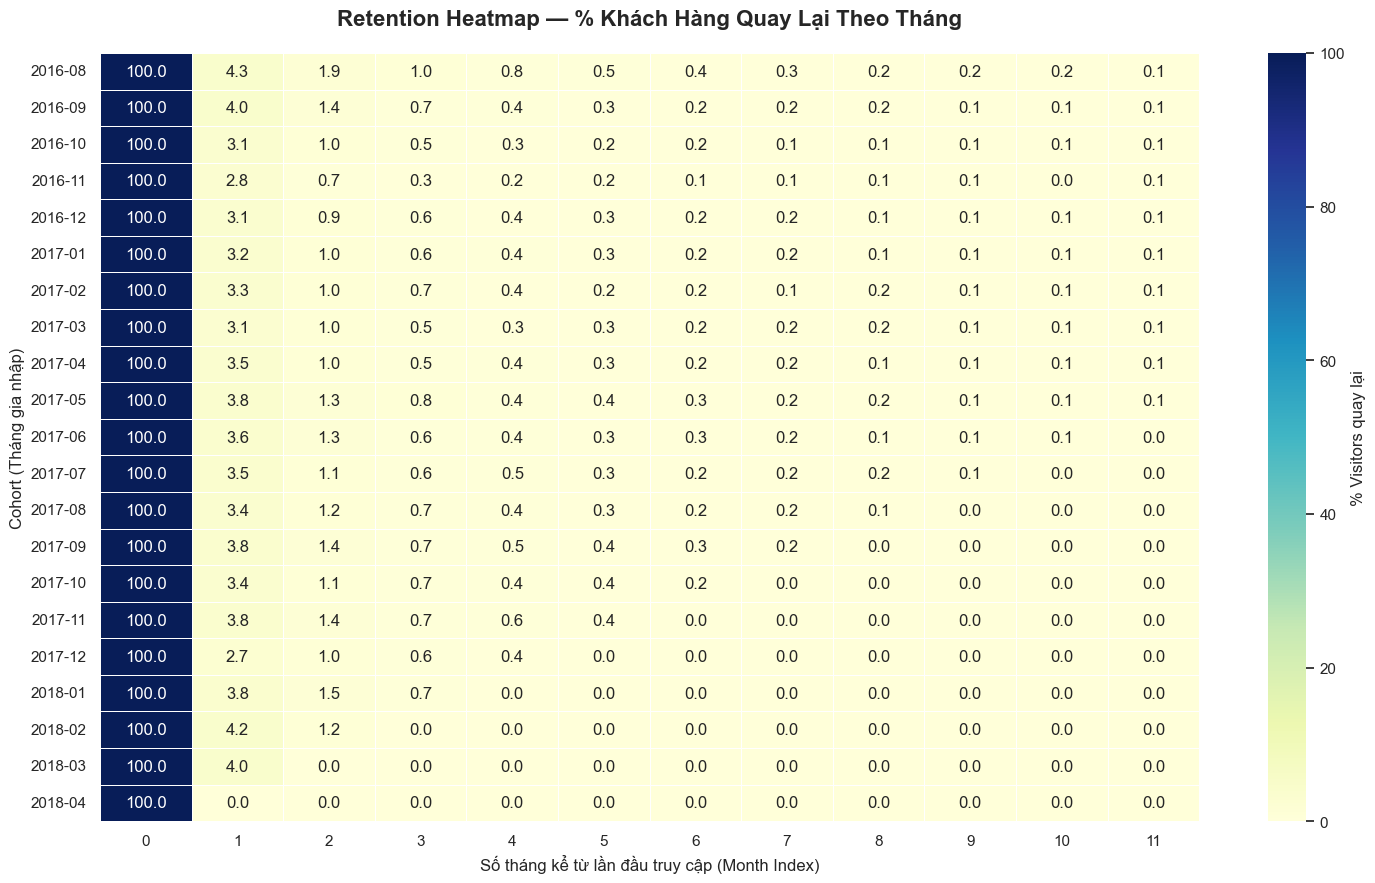

Kích thước các Cohort (Số lượng User mới mỗi tháng):
cohort_month
2016-08    61699
2016-09    56481
2016-10    81488
2016-11    95764
2016-12    59378
2017-01    49572
2017-02    48310
2017-03    54709
2017-04    52424
2017-05    48656
2017-06    48673
2017-07    55118
2017-08    65568
2017-09    66810
2017-10    76192
2017-11    70057
2017-12    74213
2018-01    63085
2018-02    63677
2018-03    70466
2018-04    61390
Freq: M, Name: 0, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tìm tháng đầu tiên mỗi visitor xuất hiện (Cohort)
first_visit = full_df.groupby('fullVisitorId')['date'].min().reset_index()
first_visit.columns = ['fullVisitorId', 'first_date']

# FIX: Thay 'first_visit' bằng 'first_date'
first_visit['cohort_month'] = first_visit['first_date'].dt.to_period('M')

# 2. Merge cohort vào bảng chính và tính tháng truy cập (Visit Month)
df_cohort = full_df.merge(first_visit, on='fullVisitorId')
df_cohort['visit_month'] = df_cohort['date'].dt.to_period('M')

# 3. Tính khoảng cách tháng (0 = tháng đầu, 1 = tháng thứ hai, ...)
df_cohort['month_number'] = (
    df_cohort['visit_month'] - df_cohort['cohort_month']
).apply(lambda x: x.n)

# 4. Tạo bảng Pivot đếm số lượng visitor unique
retention = df_cohort.groupby(
    ['cohort_month', 'month_number']
)['fullVisitorId'].nunique().unstack(fill_value=0)

# 5. Tính tỷ lệ % Retention (Chia cho số lượng visitor ở tháng 0 của mỗi cohort)
# Sử dụng iloc[:, 0] để lấy cột đầu tiên (tháng index 0) làm mốc 100%
cohort_size = retention.iloc[:, 0]
retention_pct = retention.div(cohort_size, axis=0) * 100

# 6. Vẽ Heatmap
plt.figure(figsize=(15, 9))
sns.heatmap(
    retention_pct.iloc[:, :12],  # Xem diễn biến trong 12 tháng đầu
    annot=True, 
    fmt='.1f',                  # Hiển thị 1 chữ số thập phân cho chính xác
    cmap='YlGnBu',              # Màu xanh (Đậm = Retention cao, Nhạt = Thấp)
    linewidths=0.5,
    cbar_kws={'label': '% Visitors quay lại'}
)

# Tinh chỉnh giao diện
plt.title('Retention Heatmap — % Khách Hàng Quay Lại Theo Tháng', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số tháng kể từ lần đầu truy cập (Month Index)', fontsize=12)
plt.ylabel('Cohort (Tháng gia nhập)', fontsize=12)

# Lưu và hiển thị
plt.tight_layout()
plt.savefig('retention_heatmap_fixed.png', dpi=150)
plt.show()

# In ra bảng số lượng để kiểm tra nhanh
print("Kích thước các Cohort (Số lượng User mới mỗi tháng):")
print(cohort_size)


In [ ]:
# Lấy ngày mua đầu tiên của mỗi buyer
first_buy = full_df[full_df['transactionRevenue'] > 0]\
    .groupby('fullVisitorId')['date'].min().reset_index()
first_buy.columns = ['fullVisitorId', 'first_buy_date']

# Ghép với ngày first visit
ttb = first_buy.merge(first_visit, on='fullVisitorId')
ttb['days_to_buy'] = (ttb['first_buy_date'] - ttb['first_date']).dt.days

print(f"Time-to-Buy trung bình : {ttb['days_to_buy'].mean():.1f} ngày")
print(f"Time-to-Buy median     : {ttb['days_to_buy'].median():.1f} ngày")
print(f"Mua ngay lần đầu       : {(ttb['days_to_buy']==0).mean()*100:.1f}%")
print(f"Mua trong 7 ngày       : {(ttb['days_to_buy']<=7).mean()*100:.1f}%")
print(f"Mua trong 30 ngày      : {(ttb['days_to_buy']<=30).mean()*100:.1f}%")

# → Nếu median = 0: hầu hết mua ngay lần đầu → 
# → Nếu median = 20: phải dự báo xa hơn chu kỳ mua bình thường

Time-to-Buy trung bình : 11.7 ngày
Time-to-Buy median     : 0.0 ngày
Mua ngay lần đầu       : 60.1%
Mua trong 7 ngày       : 77.1%
Mua trong 30 ngày      : 90.2%


### 4. Target Distribution

In [18]:
import numpy as np

# Tính revenue theo từng visitor
visitor_revenue = full_df.groupby('fullVisitorId')\
    ['transactionRevenue'].sum().sort_values(ascending=False)

# Chỉ lấy buyer
buyer_revenue = visitor_revenue[visitor_revenue > 0]
total_rev = buyer_revenue.sum()
cumsum    = buyer_revenue.cumsum()

# Tính đóng góp của top X%
for pct in [0.01, 0.05, 0.10, 0.20]:
    n = int(len(buyer_revenue) * pct)
    contrib = cumsum.iloc[n] / total_rev * 100
    print(f"Top {pct*100:.0f}% buyers → {contrib:.1f}% revenue")

# Kỳ vọng thấy: top 1% đóng góp 50-80% revenue
# → Pareto cực đoan → model cần học tốt với rare high-value buyers

Top 1% buyers → 28.0% revenue
Top 5% buyers → 50.5% revenue
Top 10% buyers → 62.8% revenue
Top 20% buyers → 75.3% revenue


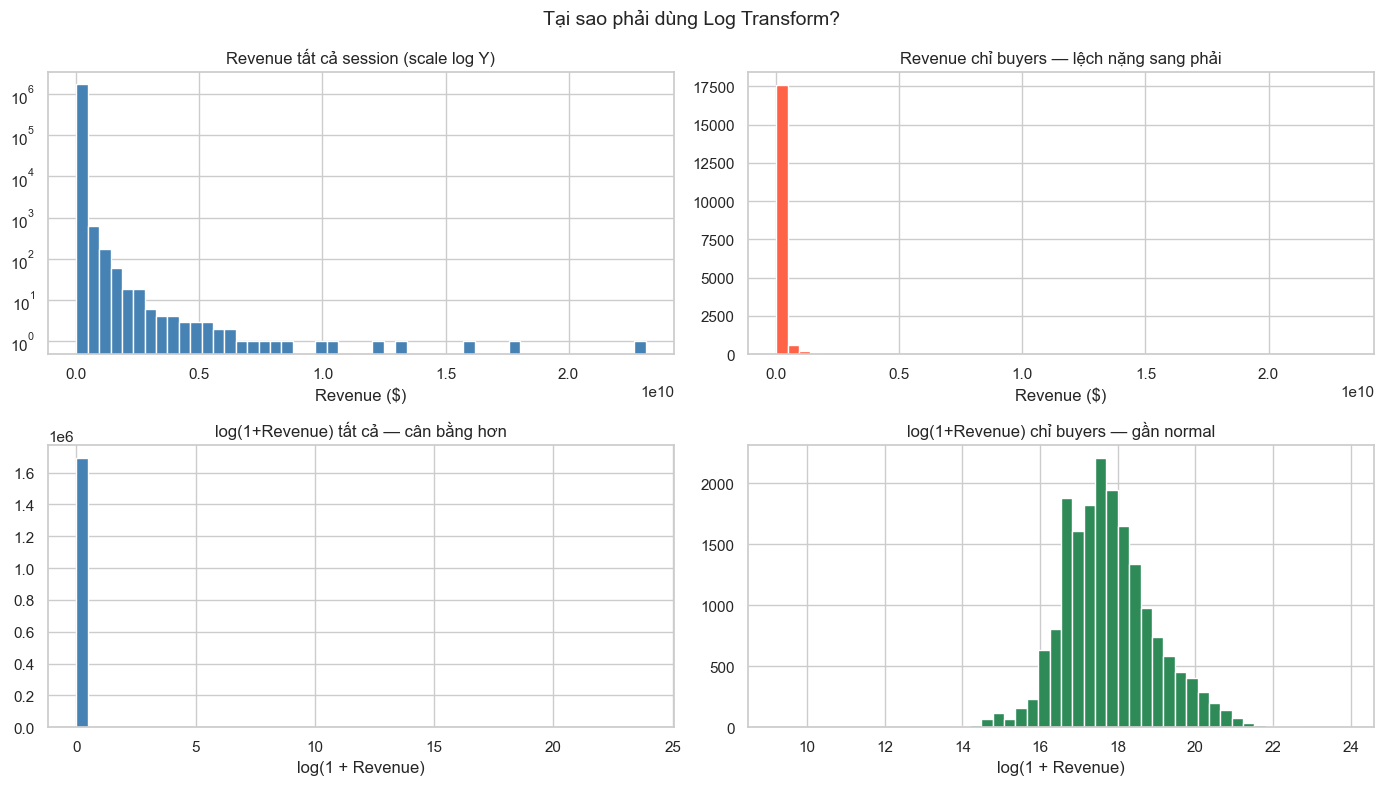

Skewness trước log: 24.89
Skewness sau log  : 0.38


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

rev_all   = full_df['transactionRevenue']
rev_buyer = full_df[full_df['transactionRevenue'] > 0]['transactionRevenue']

# Raw distribution — tất cả (gồm 0)
axes[0,0].hist(rev_all, bins=50, color='steelblue', log=True)
axes[0,0].set_title('Revenue tất cả session (scale log Y)')
axes[0,0].set_xlabel('Revenue ($)')

# Raw distribution — chỉ buyer
axes[0,1].hist(rev_buyer, bins=50, color='tomato')
axes[0,1].set_title('Revenue chỉ buyers — lệch nặng sang phải')
axes[0,1].set_xlabel('Revenue ($)')

# Log transform — tất cả
axes[1,0].hist(np.log1p(rev_all), bins=50, color='steelblue')
axes[1,0].set_title('log(1+Revenue) tất cả — cân bằng hơn')
axes[1,0].set_xlabel('log(1 + Revenue)')

# Log transform — chỉ buyer
axes[1,1].hist(np.log1p(rev_buyer), bins=50, color='seagreen')
axes[1,1].set_title('log(1+Revenue) chỉ buyers — gần normal')
axes[1,1].set_xlabel('log(1 + Revenue)')

plt.suptitle('Tại sao phải dùng Log Transform?', fontsize=14)
plt.tight_layout()
plt.savefig('log_transform_validation.png', dpi=150)
plt.show()

# Đo độ lệch (skewness) trước và sau
print(f"Skewness trước log: {rev_buyer.skew():.2f}")
print(f"Skewness sau log  : {np.log1p(rev_buyer).skew():.2f}")
# → Sau log, skewness gần 0 hơn nhiều → model hội tụ tốt hơn

### 5. High Cardinality

In [20]:
cat_cols = [
    'device_browser', 'geoNetwork_country', 
    'geoNetwork_city', 'trafficSource_source',
    'channelGrouping', 'device_deviceCategory'
]

print("=== HIGH CARDINALITY AUDIT ===\n")
for col in cat_cols:
    vc    = full_df[col].value_counts(normalize=True)
    total = len(vc)
    
    # Bao nhiêu category chiếm >= 1% mỗi cái
    major = (vc >= 0.01).sum()
    minor = (vc < 0.01).sum()
    
    # Top 1 chiếm bao nhiêu %
    top1_pct = vc.iloc[0] * 100
    
    # Top N category chiếm bao nhiêu % tổng traffic
    top5_pct  = vc.head(5).sum()  * 100
    top10_pct = vc.head(10).sum() * 100
    
    print(f"[{col}]")
    print(f"  Total unique   : {total}")
    print(f"  Chiếm >= 1%    : {major} categories")
    print(f"  Chiếm < 1%     : {minor} categories (→ gộp Other)")
    print(f"  Top 1 category : {vc.index[0]} ({top1_pct:.1f}%)")
    print(f"  Top 5 cover    : {top5_pct:.1f}% traffic")
    print(f"  Top 10 cover   : {top10_pct:.1f}% traffic")
    print()

=== HIGH CARDINALITY AUDIT ===

[device_browser]
  Total unique   : 128
  Chiếm >= 1%    : 6 categories
  Chiếm < 1%     : 122 categories (→ gộp Other)
  Top 1 category : Chrome (68.7%)
  Top 5 cover    : 94.8% traffic
  Top 10 cover   : 99.2% traffic

[geoNetwork_country]
  Total unique   : 227
  Chiếm >= 1%    : 18 categories
  Chiếm < 1%     : 209 categories (→ gộp Other)
  Top 1 category : United States (42.0%)
  Top 5 cover    : 57.8% traffic
  Top 10 cover   : 67.7% traffic

[geoNetwork_city]
  Total unique   : 954
  Chiếm >= 1%    : 22 categories
  Chiếm < 1%     : 932 categories (→ gộp Other)
  Top 1 category : Mountain View (10.4%)
  Top 5 cover    : 29.9% traffic
  Top 10 cover   : 40.6% traffic

[trafficSource_source]
  Total unique   : 344
  Chiếm >= 1%    : 5 categories
  Chiếm < 1%     : 339 categories (→ gộp Other)
  Top 1 category : google (38.5%)
  Top 5 cover    : 95.1% traffic
  Top 10 cover   : 97.2% traffic

[channelGrouping]
  Total unique   : 8
  Chiếm >= 1%    :

In [21]:
print("=== KẾT LUẬN & QUYẾT ĐỊNH XỬ LÝ ===")
for col in cat_cols:
    vc    = full_df[col].value_counts(normalize=True)
    minor = (vc < 0.01).sum()
    pct   = minor / len(vc) * 100
    print(f"{col}: {minor} categories < 1% ({pct:.0f}% số unique)"
          f" → gộp vào 'Other' để tránh overfitting")

=== KẾT LUẬN & QUYẾT ĐỊNH XỬ LÝ ===
device_browser: 122 categories < 1% (95% số unique) → gộp vào 'Other' để tránh overfitting
geoNetwork_country: 209 categories < 1% (92% số unique) → gộp vào 'Other' để tránh overfitting
geoNetwork_city: 932 categories < 1% (98% số unique) → gộp vào 'Other' để tránh overfitting
trafficSource_source: 339 categories < 1% (99% số unique) → gộp vào 'Other' để tránh overfitting
channelGrouping: 1 categories < 1% (12% số unique) → gộp vào 'Other' để tránh overfitting
device_deviceCategory: 0 categories < 1% (0% số unique) → gộp vào 'Other' để tránh overfitting


## Preprocessing Data

#### 1. Loại bỏ internal traffic + bot

In [22]:
junk_mask = internal_mask | bot_mask | tracking_error_mask | fake_whale_mask
full_df_cleaned = full_df[~junk_mask].reset_index(drop=True)
print(f"\nKích thước DataFrame cũ: {full_df.shape}")
print(f"Kích thước DataFrame mới: {full_df_cleaned.shape}")
full_df = full_df_cleaned


Kích thước DataFrame cũ: (1708337, 60)
Kích thước DataFrame mới: (1623718, 60)
